In [1]:
import pandas as pd
df=pd.read_csv("D:3\lahore_food_delivery_raw_2024_2025.csv")

In [19]:
df.isnull().sum()

order_id                   0
order_datetime             0
customer_id             1024
area                     769
payment_method          1179
restaurant_category        0
restaurant_name          513
items_count              768
order_value_pkr          508
delivery_fee_pkr        1023
distance_km             1270
rider_id                1519
vehicle_type               0
weather                 2049
prep_time_min           1518
delivery_time_min       2515
order_status               0
customer_rating         3018
is_ramadan                 0
cancel_reason          48245
dtype: int64

In [20]:
df["order_datetime"] = pd.to_datetime(df["order_datetime"],format="mixed",dayfirst=True,errors="coerce")

In [21]:
cols=["order_value_pkr","delivery_fee_pkr"]
for col in cols:
    df[col]=(
        df[col].astype(str)
        .str.replace(r'Rs\.?|Rs','',regex=True)
        .str.strip()
    )
    df[col]=pd.to_numeric(df[col],errors="coerce")

In [22]:
#SOLVING THE NULL VALUE PROBLEM
df["cancel_reason"]=df["cancel_reason"].fillna("Not canceled")

num_cols=['delivery_fee_pkr', 'order_value_pkr', 'distance_km', 'prep_time_min', 'delivery_time_min', 'items_count']
for col in cols:
    df[col]=df[col].fillna(df[col].median())

In [23]:
#Categorical columns
df["weather"]=df["weather"].fillna(df["weather"].mode()[0])
df["payment_method"]=df["payment_method"].fillna("Unknow")
df["area"]=df["area"].fillna("Unknow")
df["restaurant_name"]=df["restaurant_name"].fillna("Unknow")

In [24]:
cols_to_fix = ['distance_km', 'prep_time_min', 'delivery_time_min', 'items_count']

for col in cols_to_fix:
    if col in df.columns:
        # Extract from actual list or strip bracket characters
        df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
        df[col] = df[col].astype(str).str.strip("[]'\" ")
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [25]:
# Impute prep_time_min and delivery_time_min by area & restaurant_category for delivered orders
delivered_mask = df['order_status'] == 'Delivered'

df.loc[delivered_mask, 'prep_time_min'] = df.loc[delivered_mask].groupby(
    ['area', 'restaurant_category']
)['prep_time_min'].transform(lambda x: x.fillna(x.median()))

df.loc[delivered_mask, 'delivery_time_min'] = df.loc[delivered_mask].groupby(
    ['area', 'distance_km']
)['delivery_time_min'].transform(lambda x: x.fillna(x.median()))

# Fallback to overall median if any delivered row is still NaN
df.loc[delivered_mask, 'prep_time_min'] = df.loc[delivered_mask, 'prep_time_min'].fillna(df['prep_time_min'].median())
df.loc[delivered_mask, 'delivery_time_min'] = df.loc[delivered_mask, 'delivery_time_min'].fillna(df['delivery_time_min'].median())

In [26]:
#Solving null value in distance
df['distance_km']=df.groupby('area')['distance_km'].transform(lambda x:x.fillna(x.median()))
df['distance_km']=df['distance_km'].fillna(df['distance_km'].median())

In [27]:
#Solving null in item_counts
df['items_count']=df['items_count'].fillna(df['items_count'].median())

In [28]:
df['rider_id']=df['rider_id'].fillna("Unassigned")

In [29]:
# 1. Temporal breakdown
df['order_hour'] = df['order_datetime'].dt.hour
df['day_name'] = df['order_datetime'].dt.day_name()

# 2. Peak Lahore Demand Flags
# Iftar rush (typically ~5:00 PM to 7:30 PM during Ramadan)
df['is_iftar_rush'] = df['is_ramadan'].astype(bool) & df['order_hour'].isin([17, 18, 19])

# Dinner peak (8:00 PM to 11:00 PM)
df['is_dinner_peak'] = df['order_hour'].isin([20, 21, 22, 23])

# 3. Define Delay Metric (e.g., total turnaround time > threshold or expected SLA)
# Total order duration = prep_time + delivery_time
df['total_duration_min'] = df['prep_time_min'] + df['delivery_time_min']

# Standard delivery benchmark (e.g., > 45 mins is delayed)
df['is_delayed'] = (df['order_status'] == 'Delivered') & (df['total_duration_min'] > 45)
df['is_cancelled'] = df['order_status'] == 'Cancelled'

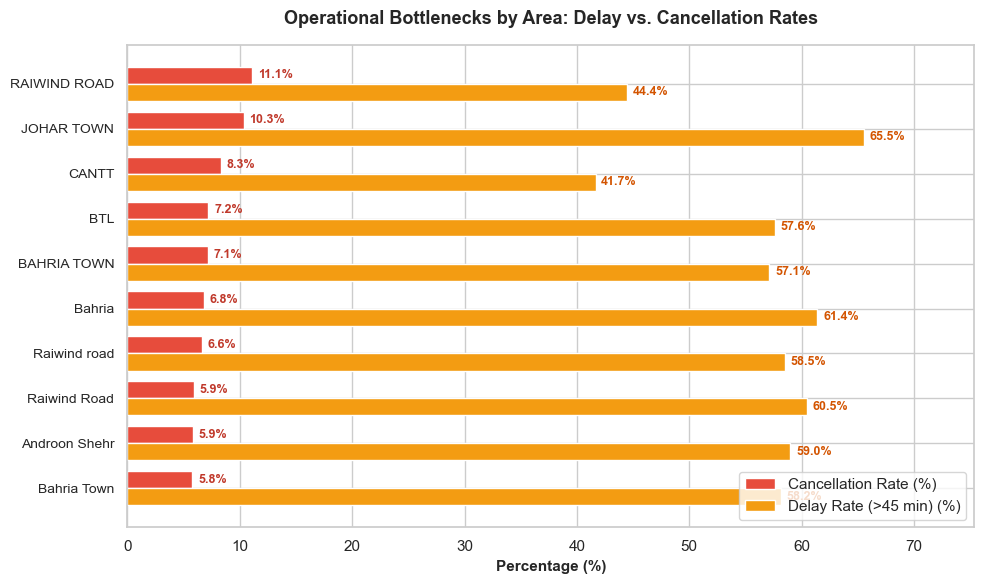

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Prepare data: top areas sorted by cancel rate
plot_area = area_summary.sort_values(by="cancel_rate_pct", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))

y_indices = range(len(plot_area))
bar_height = 0.38

# Plot Cancel Rate and Delay Rate bars
bars_cancel = ax.barh([y + bar_height/2 for y in y_indices], plot_area["cancel_rate_pct"], 
                      height=bar_height, label="Cancellation Rate (%)", color="#e74c3c")
bars_delay = ax.barh([y - bar_height/2 for y in y_indices], plot_area["delay_rate_pct"], 
                     height=bar_height, label="Delay Rate (>45 min) (%)", color="#f39c12")

# Annotate percentages at the end of each bar
for bar in bars_cancel:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", 
            va="center", ha="left", fontsize=9, fontweight="bold", color="#c0392b")

for bar in bars_delay:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", 
            va="center", ha="left", fontsize=9, fontweight="bold", color="#d35400")

ax.set_yticks(list(y_indices))
ax.set_yticklabels(plot_area.index, fontsize=10)
ax.set_xlabel("Percentage (%)", fontsize=11, fontweight="bold")
ax.set_title("Operational Bottlenecks by Area: Delay vs. Cancellation Rates", fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="lower right", frameon=True)
ax.set_xlim(0, max(plot_area[["cancel_rate_pct", "delay_rate_pct"]].max()) * 1.15)

plt.tight_layout()
plt.show()

In [35]:
df.to_csv("D:3\lahore_food_delivery_raw_2024_2025.csv", index=False)

In [1]:
pip install pandas openpyxl mysql-connector-python sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sqlalchemy import create_engine

# --- Database & File Configuration ---
DB_USER = "root"
DB_PASS = "1234"
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "Lahore"

CSV_FILE = ("D:3\lahore_food_delivery_raw_2024_2025.csv")     # Replace with your CSV file path
TABLE_NAME = "csv_records"   # Name of the table to create in MySQL

# --- 1. Read CSV File ---
print("Reading CSV file...")
# If your CSV uses a different delimiter (like semicolon or tab), add: sep=';' or sep='\t'
df = pd.read_csv(CSV_FILE)

# Clean column names (removes leading/trailing spaces that cause SQL errors)
df.columns = df.columns.str.strip()

# --- 2. Connect to MySQL ---
connection_url = f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_url)

# --- 3. Push to Database ---
print(f"Uploading {len(df)} rows to table '{TABLE_NAME}' in database '{DB_NAME}'...")

df.to_sql(
    name=TABLE_NAME,
    con=engine,
    if_exists="replace",  # Use "append" if you want to add data without overwriting
    index=False,
    chunksize=2000        # Pushes 2,000 rows at a time for optimal speed
)

print("Data uploaded successfully!")

Reading CSV file...
Uploading 51150 rows to table 'csv_records' in database 'Lahore'...
Data uploaded successfully!
